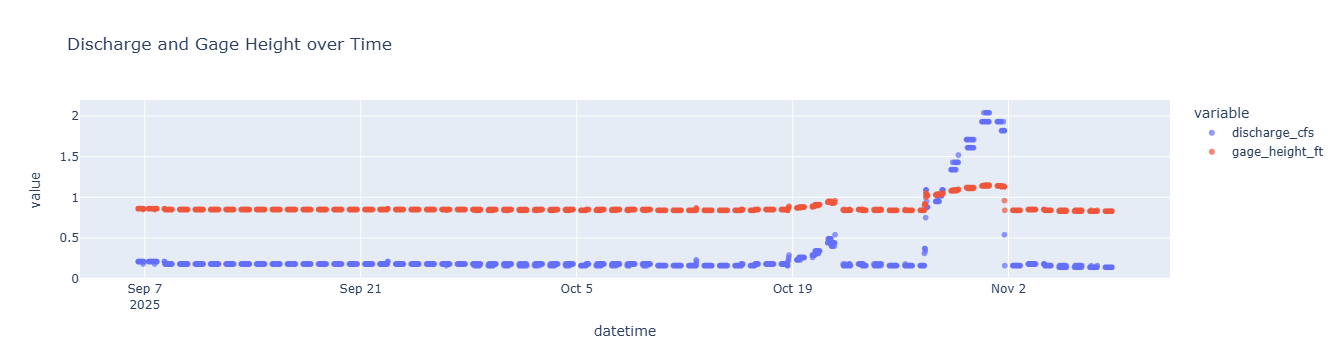

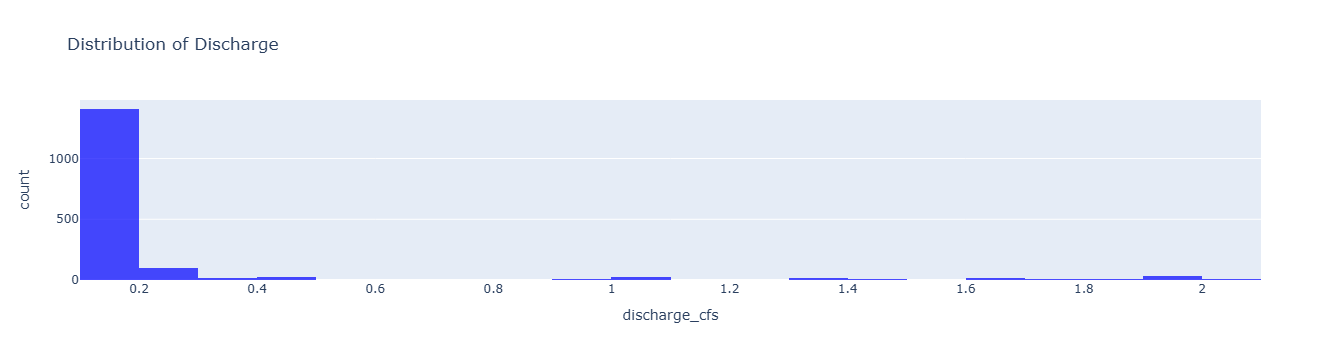

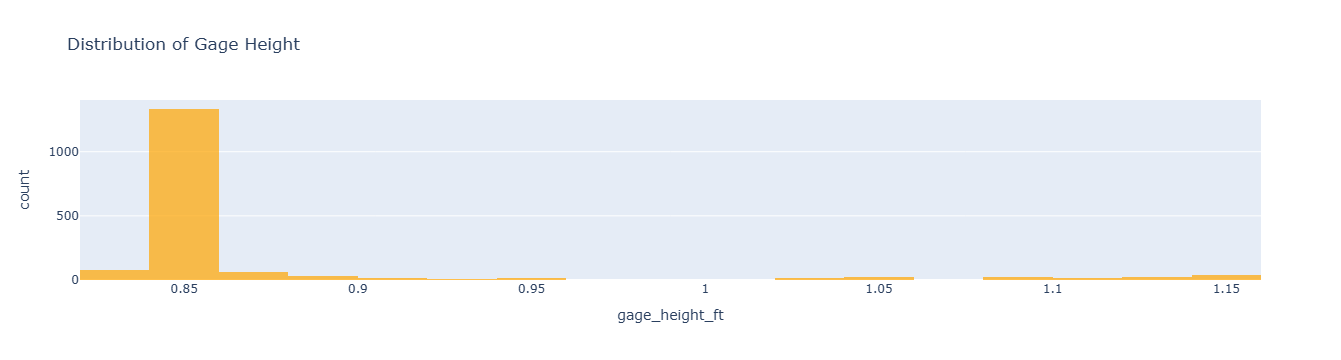

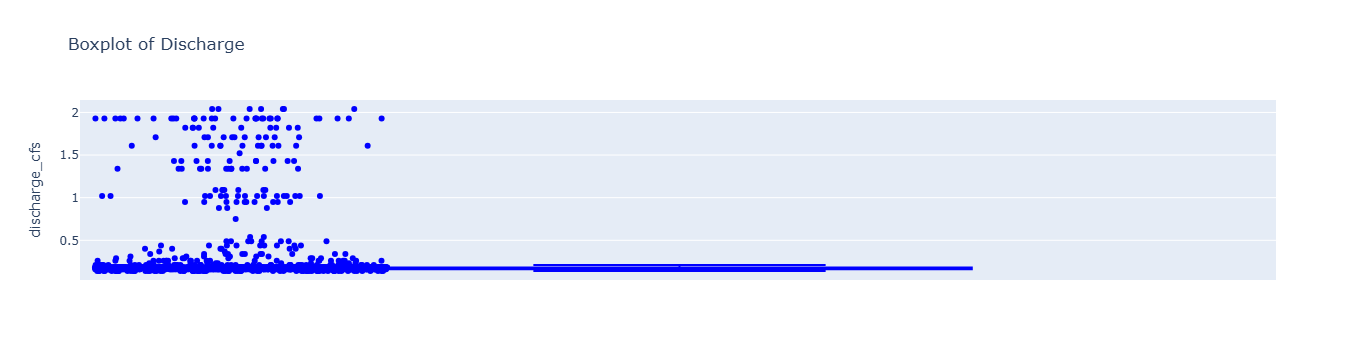

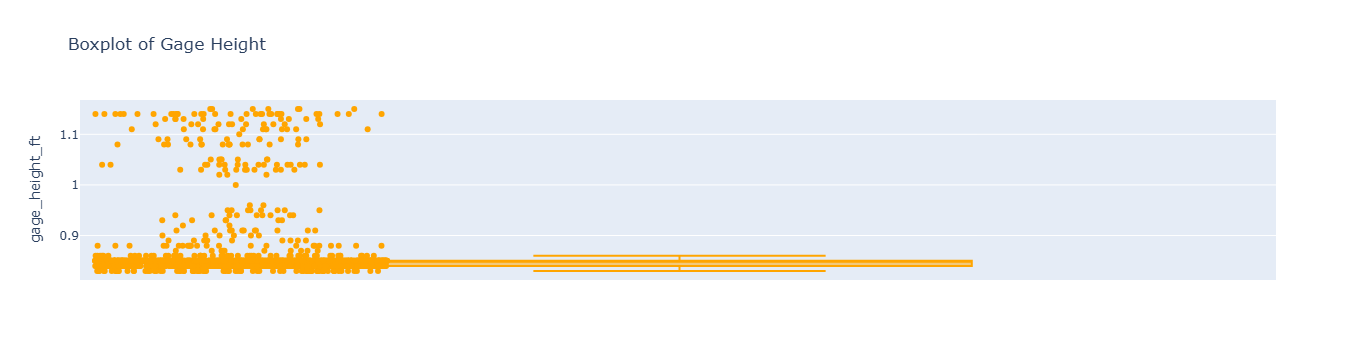

In [2]:
# this code takes a datasheet as input and displays information about the data
# plot gage readings over timestamps

import pandas as pd
import plotly.express as px

# -----------------------------
# Load Excel data
# -----------------------------
df = pd.read_excel("pukele_datasheet.xlsx")  # replace with your file path

# Combine date and time into a single datetime column
df['time_str'] = df['time'].astype(str)
df['datetime'] = pd.to_datetime(df['date'].dt.strftime('%Y-%m-%d') + ' ' + df['time_str'])

# -----------------------------
# 1. Scatter plot: discharge and gage_height over time
# -----------------------------
# Melt the dataframe to long format so we can color by variable
df_long = df.melt(
    id_vars=['datetime', 'path'],
    value_vars=['discharge_cfs', 'gage_height_ft'],
    var_name='variable',
    value_name='value'
)

fig_scatter = px.scatter(
    df_long,
    x='datetime',
    y='value',
    color='variable',  # different color for discharge vs gage height
    hover_data=['path'],
    title='Discharge and Gage Height over Time'
)
fig_scatter.update_traces(marker=dict(size=6, opacity=0.7))
fig_scatter.show()

# -----------------------------
# 2. Histograms: separate for discharge and gage_height
# -----------------------------
fig_hist_discharge = px.histogram(
    df,
    x='discharge_cfs',
    nbins=30,
    title='Distribution of Discharge',
    hover_data=['path']
)
fig_hist_discharge.update_traces(marker_color='blue', opacity=0.7)
fig_hist_discharge.show()

fig_hist_gage = px.histogram(
    df,
    x='gage_height_ft',
    nbins=30,
    title='Distribution of Gage Height',
    hover_data=['path']
)
fig_hist_gage.update_traces(marker_color='orange', opacity=0.7)
fig_hist_gage.show()

# -----------------------------
# 3. Box plots: separate for discharge and gage_height
# -----------------------------
fig_box_discharge = px.box(
    df,
    y='discharge_cfs',
    points='all',
    hover_data=['path', 'datetime'],
    title='Boxplot of Discharge'
)
fig_box_discharge.update_traces(marker_color='blue', jitter=0.5)
fig_box_discharge.show()

fig_box_gage = px.box(
    df,
    y='gage_height_ft',
    points='all',
    hover_data=['path', 'datetime'],
    title='Boxplot of Gage Height'
)
fig_box_gage.update_traces(marker_color='orange', jitter=0.5)
fig_box_gage.show()


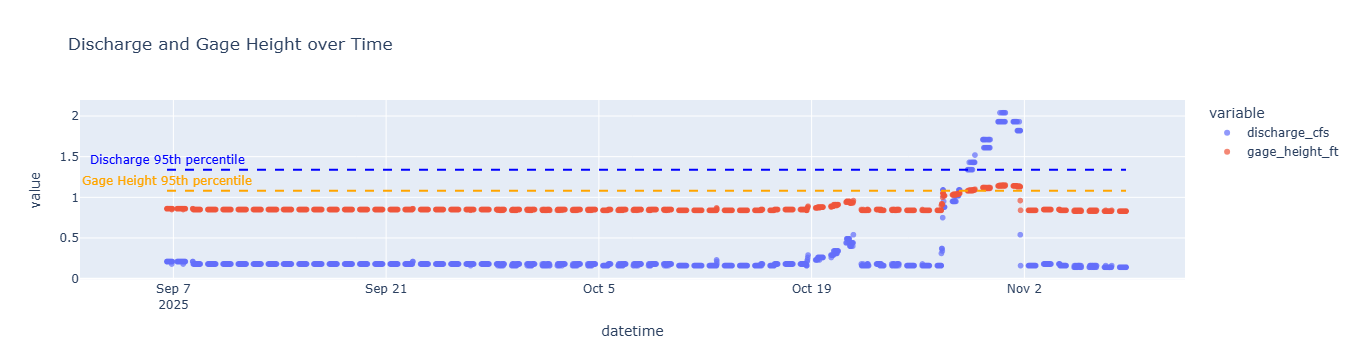

In [4]:
import pandas as pd
import plotly.express as px
import numpy as np

# -----------------------------
# Load Excel data
# -----------------------------
df = pd.read_excel("pukele_datasheet.xlsx")

# Combine date and time into a single datetime column
df['time_str'] = df['time'].astype(str)
df['datetime'] = pd.to_datetime(df['date'].dt.strftime('%Y-%m-%d') + ' ' + df['time_str'])

# -----------------------------
# Scatter plot with threshold lines
# -----------------------------
# Melt the dataframe to long format for coloring
df_long = df.melt(
    id_vars=['datetime', 'path'],
    value_vars=['discharge_cfs', 'gage_height_ft'],
    var_name='variable',
    value_name='value'
)

fig_scatter = px.scatter(
    df_long,
    x='datetime',
    y='value',
    color='variable',
    hover_data=['path'],
    title='Discharge and Gage Height over Time'
)
fig_scatter.update_traces(marker=dict(size=6, opacity=0.7))

# -----------------------------
# Add horizontal lines for given percentile
# -----------------------------
percentile = 95  # e.g., line above which 10% of data lies

# Compute thresholds
discharge_thresh = np.percentile(df['discharge_cfs'], percentile)
gage_thresh = np.percentile(df['gage_height_ft'], percentile)

# Add horizontal lines using add_shape
fig_scatter.add_shape(
    type="line",
    x0=df['datetime'].min(),
    x1=df['datetime'].max(),
    y0=discharge_thresh,
    y1=discharge_thresh,
    line=dict(color="blue", width=2, dash="dash"),
    name=f"Discharge {percentile}th percentile"
)
fig_scatter.add_shape(
    type="line",
    x0=df['datetime'].min(),
    x1=df['datetime'].max(),
    y0=gage_thresh,
    y1=gage_thresh,
    line=dict(color="orange", width=2, dash="dash"),
    name=f"Gage Height {percentile}th percentile"
)

# Optionally, add annotations to label the lines
fig_scatter.add_annotation(
    x=df['datetime'].min(),
    y=discharge_thresh,
    text=f"Discharge {percentile}th percentile",
    showarrow=False,
    yshift=10,
    font=dict(color="blue")
)
fig_scatter.add_annotation(
    x=df['datetime'].min(),
    y=gage_thresh,
    text=f"Gage Height {percentile}th percentile",
    showarrow=False,
    yshift=10,
    font=dict(color="orange")
)

fig_scatter.show()
